In [2]:
import pandas as pd

df = pd.read_csv(
    "../data/forecasting_dataset.csv"
)



In [3]:
df = df.sort_values(
    ["date", "Local area"]
)
df.head()

,date,Local area,request_count,lag_1,lag_7,rolling_mean_7,day_of_week,month,weekend,lag_14,rolling_mean_30
0,2022-02-06,Arbutus Ridge,9,11,9,14,6,2,1,4.0,17.733333
1547,2022-02-06,Downtown,36,47,36,66,6,2,1,38.0,72.566667
3098,2022-02-06,Dunbar-Southlands,6,17,27,24,6,2,1,11.0,28.933333
4649,2022-02-06,Fairview,7,21,6,22,6,2,1,8.0,30.766667
6200,2022-02-06,Grandview-Woodland,17,21,22,33,6,2,1,9.0,39.333333


In [3]:
print(df["date"].min())
print(df["date"].max())

2022-01-08
2026-05-14


In [4]:
# encode locations
from sklearn.preprocessing import LabelEncoder


In [5]:
lb = LabelEncoder()
df["area_encoded"] = lb.fit_transform(
    df["Local area"]
)

In [6]:
# split the data into training and testing sets
# the training will be before 2026-01-01 and test will be after 

train_df = df[df["date"] < "2026-01-01"]
test_df = df[df["date"] >= "2026-01-01"]

In [7]:
y_train = train_df["request_count"]
y_test = test_df["request_count"]
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "day_of_week",
    "month",
    "weekend",
    "area_encoded"
  
]
X_train = train_df[features]
X_test = test_df[features]

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [76]:
regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)

regressor.fit(X_train, y_train)

,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.r2_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node s

In [77]:
predictions = regressor.predict(X_test)

In [78]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 62.883405393545225


In [79]:
r2 = r2_score(y_test, predictions)
print("R-squared:", r2)

R-squared: 0.7606163647138616


In [80]:
mae = mean_absolute_error(
    y_test,
    predictions
)
print("Mean absolute Error:", mae)

Mean absolute Error: 5.75162210157222


In [81]:
import pandas as pd

importance = pd.Series(
    regressor.feature_importances_,
    index=features
)

print(
    importance.sort_values(
        ascending=False
    )
)

lag_14            0.293068
rolling_mean_7    0.271943
lag_7             0.248250
lag_1             0.055413
day_of_week       0.046046
month             0.031460
area_encoded      0.030501
weekend           0.023318
dtype: float64


In [9]:
import xgboost as xgb

In [10]:
model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)

In [13]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 62.307
R²: 0.763


In [14]:
import joblib
joblib.dump(model, "../results/models/xgboost_demand_model.pkl")

['../results/models/xgboost_demand_model.pkl']

In [15]:
feature_columns = X_train.columns.tolist()
print(feature_columns)

['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'day_of_week', 'month', 'weekend', 'area_encoded']


In [14]:
joblib.dump(feature_columns, "../results/models/xgboost_feature_columns.pkl")

['../results/models/xgboost_feature_columns.pkl']

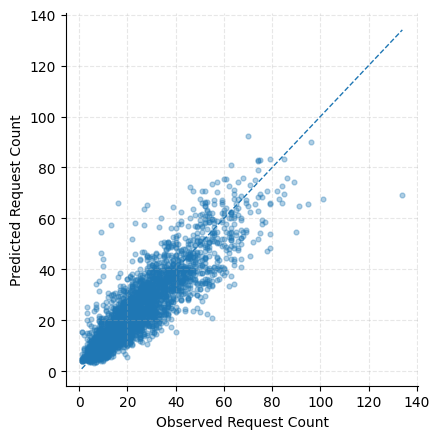

In [16]:
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.scatter(
    y_test,
    y_pred,
    alpha=0.35,
    s=12
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Observed Request Count")
ax.set_ylabel("Predicted Request Count")

ax.grid(
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("figures/actual_vs_predicted.pdf", bbox_inches="tight")
plt.savefig("figures/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

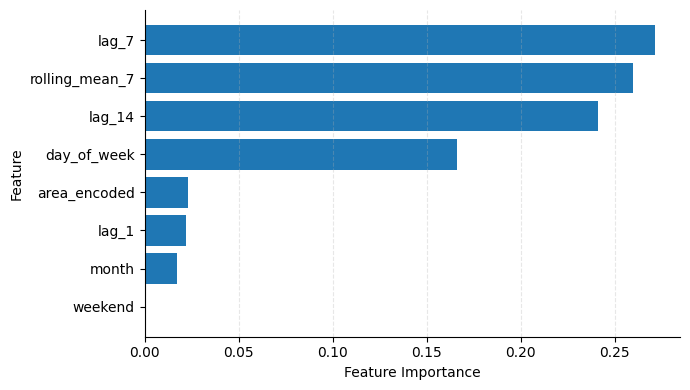

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    importance_df["feature"],
    importance_df["importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("figures/xgboost_feature_importance.pdf", bbox_inches="tight")
plt.savefig("figures/xgboost_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()